findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

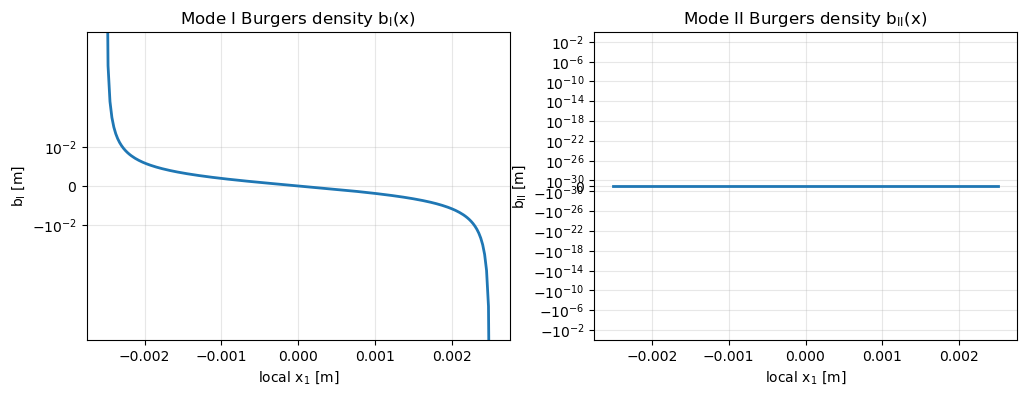

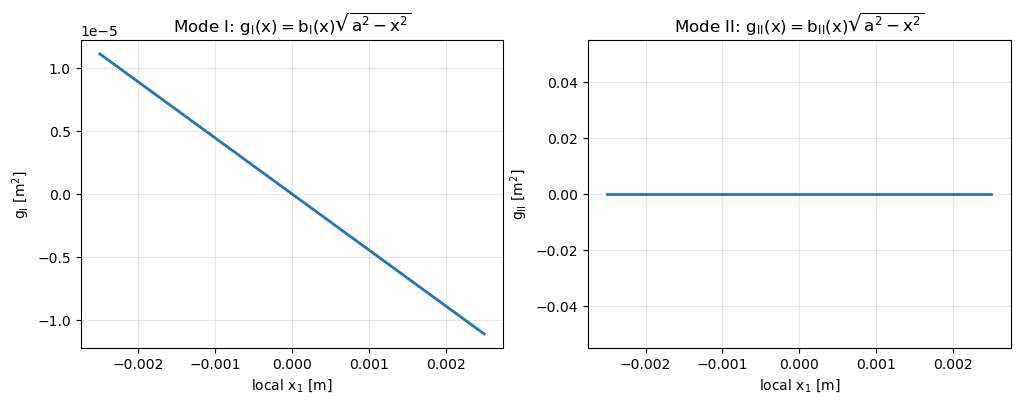

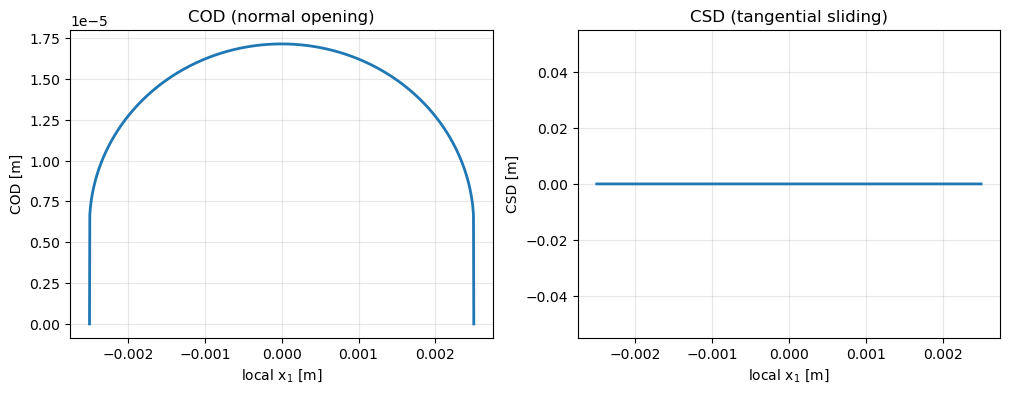

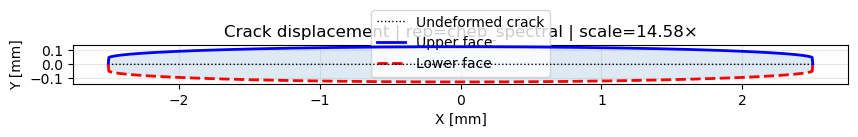

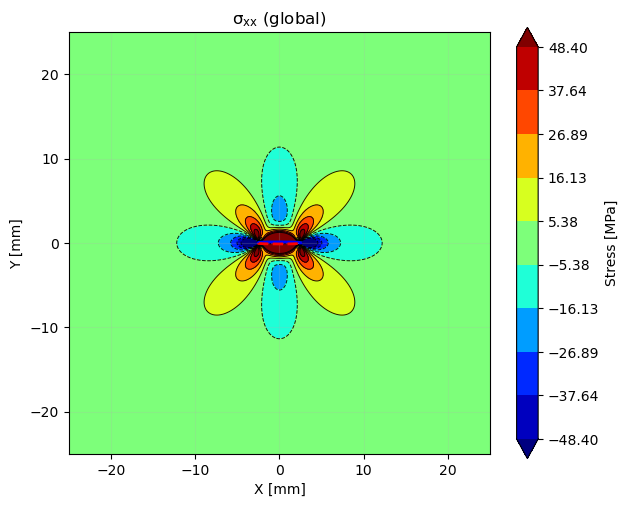

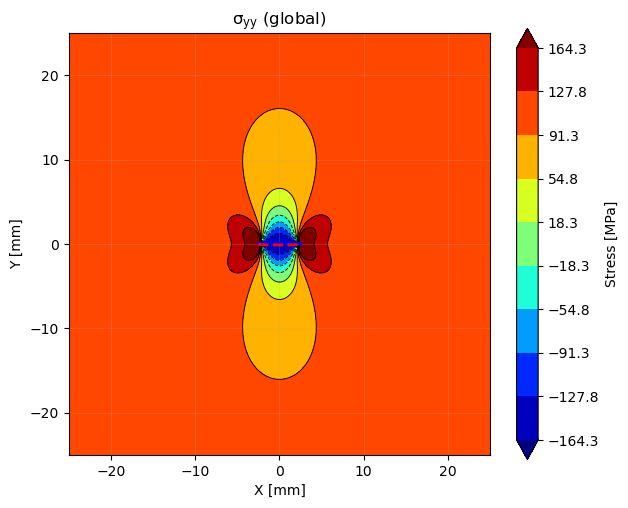

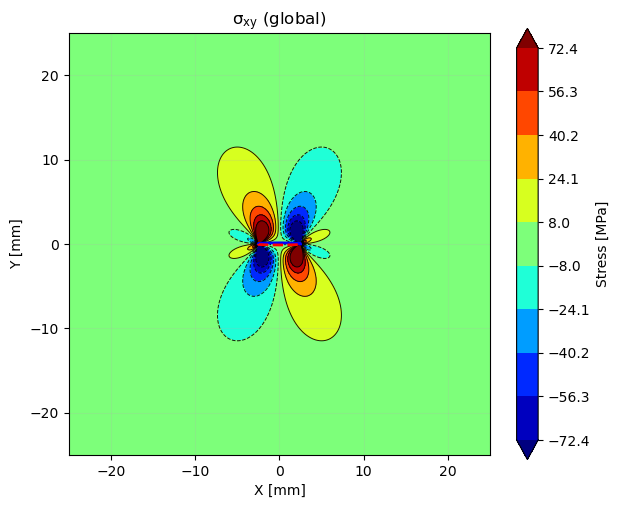

In [11]:
"""
DCE Analysis - Jupyter Notebook (clean v0)
"""

import numpy as np
import matplotlib.pyplot as plt
import os, sys

# Ensure repo root is on sys.path (so "utils" imports resolve)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from utils.dce_calcs_v0 import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_plots_v0 import DCEPlotterV0

# Inputs
ne_half = 10
theta  = np.deg2rad(0.0)
stress = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)   # GLOBAL

material = Material(E=208e9, nu=0.30, plane_stress=False)
crack    = Crack(length=5e-3, angle=theta, center=(0.0, 0.0))        # 2a [m]

calc = DCESingleCrackStatic(material, crack, stress)

# Solve (choose one)
"""
res= calc.solve(
    ne_half=ne_half,
    representation="delta_collocation",
    nq_src=2,     # DOFs per element
    nq_col=4,     # oversampled traction equations per element
    ridge=1e-14   # tiny ridge (optional, but helps conditioning)
)
"""
# res = calc.solve(ne_half=ne_half, representation="cheb_quad")
res = calc.solve(ne_half=ne_half, representation="cheb_spectral")

# Plots
plotter = DCEPlotterV0(calc, res)

# Robust b(x) plots + also show g(x)=b(x)*sqrt(a^2-x^2)
plotter.plot_burgers(
    n=200,
    yscale="symlog",          # handles tip blow-up visually
    clip_percentile=99.0,     # prevents a few extreme samples from setting the y-limits
    show_g=True               # second figure: g(x) is usually the cleanest diagnostic
)

plotter.plot_cod_csd()
plotter.plot_crack_displacement_geometry()


plotter = DCEPlotterV0(calc, res)

figs = plotter.plot_stress_field_components(
    coords="global",
    component_set="global",     # or "both"
    extent_factor=10.0,
    n_grid=401,
    cmap="jet",
    n_bands=10,
    label_contours=False,
    add_remote=True,

    # Range control:
    vmax_factor=5.0,           # 10× remote component
    vref_component="syy",       # use remote σyy as the reference
    symmetric=True,             # ±vmax
    #vmax_mpa=10000,   # Optional explicit axis limits (meters):
    # xlim=(-2.5e-3, 2.5e-3),
    # ylim=(-1.5e-3, 1.5e-3),
)
plt.show()



CODmax = 1.9623821793765946e-05 m
a [m] = 0.0025
KI_ana [MPa√m] = 8.86227
KI_num [MPa√m] = 410.64558
fit meta: {'window': 'auto', 'r_min': 2.7822439892157685e-06, 'r_max': 5.274698085403343e-06, 'dx_tip': 2.7822439892157685e-07, 'n_fit': 113, 'two_term': True, 'A_I': 0.014303827027290368, 'B_I': -4649.411275041547, 'A_II': 0.0, 'B_II': 0.0}


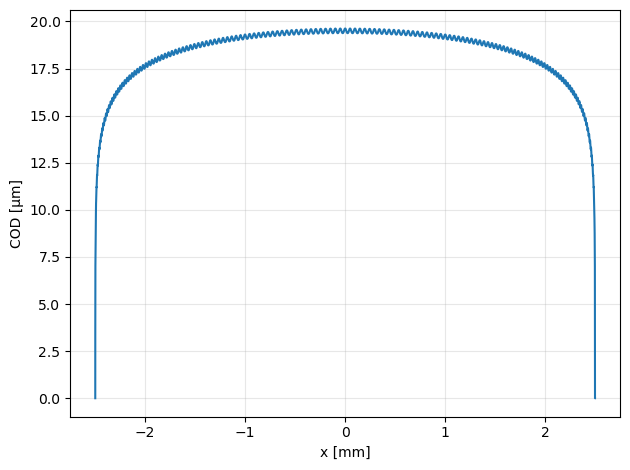

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from utils.dce_solver_v1  import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_results_v1 import DCEResultsV0

E, nu = 209e9, 0.30
sigma = 100e6

material = Material(E=E, nu=nu, plane_stress=False)  # plane strain
stress   = AppliedStress(sigma_xx=0.0, sigma_yy=sigma, sigma_xy=0.0)

ne_half = 80
node_distribution = "tip_dense"
representation = "delta_collocation"   # now should match cheb_quad scale

L = 5e-3
crack = Crack(length=L, angle=0.0, center=(0.0, 0.0))
calc  = DCESingleCrackStatic(material, crack, stress)

sol = calc.solve(ne_half=ne_half, representation=representation, node_distribution=node_distribution)
res = DCEResultsV0(calc, sol)

x, COD, CSD = res.reconstruct_cod_csd(n_theta=20000, enforce_tip_zero=True)
print("CODmax =", COD.max(), "m")

KI_num, KII_num, meta = res.sif_from_cod_fit(
    tip="right",
    window="auto",
    rho_min=5e-4, rho_max=5e-2,
    c1=10.0, c2=0.20,
    n_fit=120, n_theta=20000,
    two_term=True
)

a = crack.half_length
KI_ana = res.KI_tada_infinite(sigma, a)

print(f"a [m] = {a}")
print(f"KI_ana [MPa√m] = {KI_ana/1e6:.5f}")
print(f"KI_num [MPa√m] = {KI_num/1e6:.5f}")
print("fit meta:", meta)

plt.figure()
plt.plot(x*1e3, COD*1e6)
plt.xlabel("x [mm]")
plt.ylabel("COD [µm]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CODmax = 4.322677172821545e-06 m
a [m] = 0.0025
KI_ana [MPa√m] = 8.86227
KI_num [MPa√m] = 9.34607
fit meta: {'window': 'auto', 'r_min': 3.8533328335899585e-05, 'r_max': 9.633332083974896e-05, 'dx_tip': 3.8533328335899585e-06, 'n_fit': 120, 'two_term': True, 'A_I': 0.0003255472931926985, 'B_I': -1.2262414541366764, 'A_II': 0.0, 'B_II': 0.0}


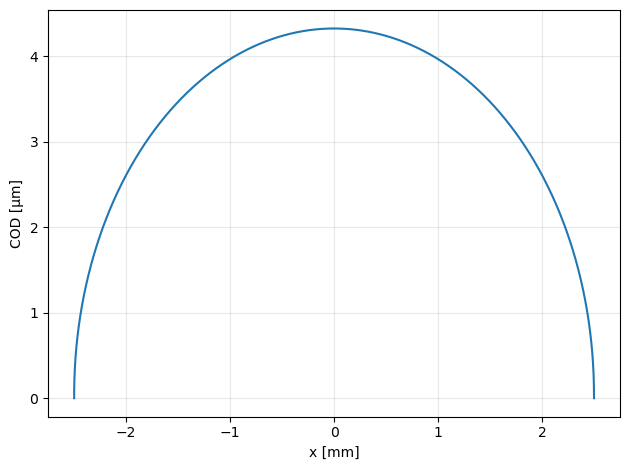

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from utils.dce_solver_v1  import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_results_v1 import DCEResultsV0

E, nu = 209e9, 0.30
sigma = 100e6

material = Material(E=E, nu=nu, plane_stress=False)  # plane strain
stress   = AppliedStress(sigma_xx=0.0, sigma_yy=sigma, sigma_xy=0.0)

ne_half = 20
node_distribution = "tip_dense"
representation = "cheb_quad"   # now should match cheb_quad scale

L = 5e-3
crack = Crack(length=L, angle=0.0, center=(0.0, 0.0))
calc  = DCESingleCrackStatic(material, crack, stress)

sol = calc.solve(ne_half=ne_half, representation=representation, node_distribution=node_distribution)
res = DCEResultsV0(calc, sol)

x, COD, CSD = res.reconstruct_cod_csd(n_theta=20000, enforce_tip_zero=True)
print("CODmax =", COD.max(), "m")

KI_num, KII_num, meta = res.sif_from_cod_fit(
    tip="right",
    window="auto",
    rho_min=5e-4, rho_max=5e-2,
    c1=10.0, c2=0.20,
    n_fit=120, n_theta=20000,
    two_term=True
)

a = crack.half_length
KI_ana = res.KI_tada_infinite(sigma, a)

print(f"a [m] = {a}")
print(f"KI_ana [MPa√m] = {KI_ana/1e6:.5f}")
print(f"KI_num [MPa√m] = {KI_num/1e6:.5f}")
print("fit meta:", meta)

plt.figure()
plt.plot(x*1e3, COD*1e6)
plt.xlabel("x [mm]")
plt.ylabel("COD [µm]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KI  [MPa√m] = 9.43236123992319
KII [MPa√m] = 0.0


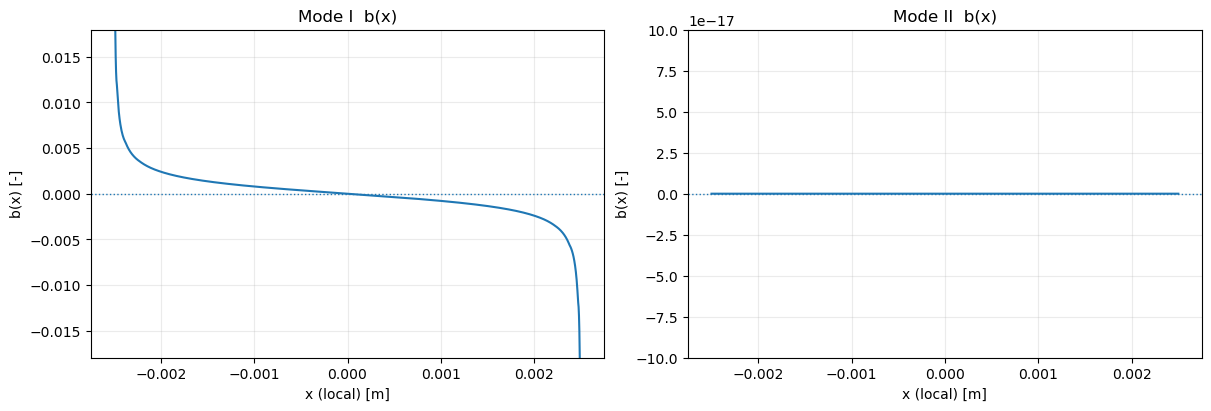

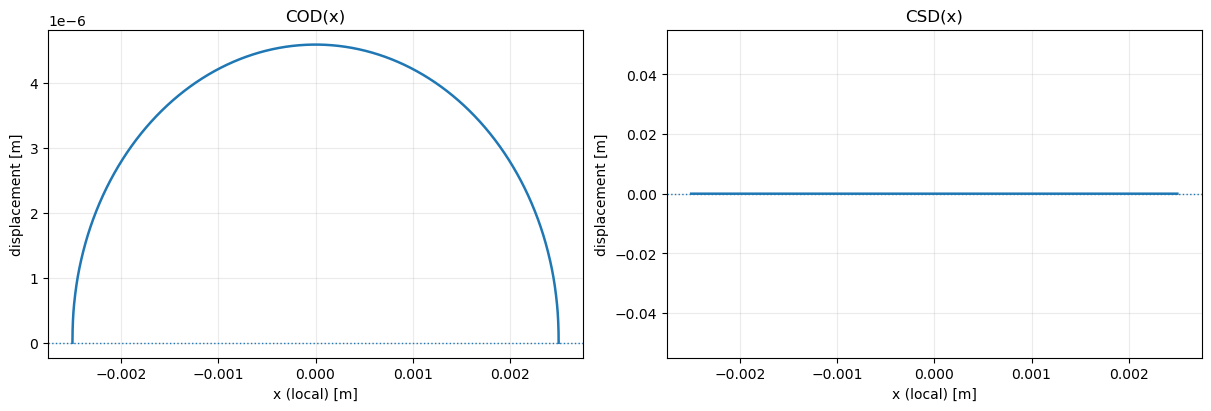

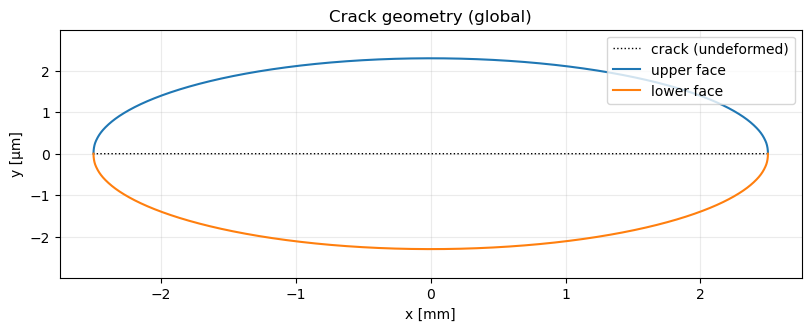

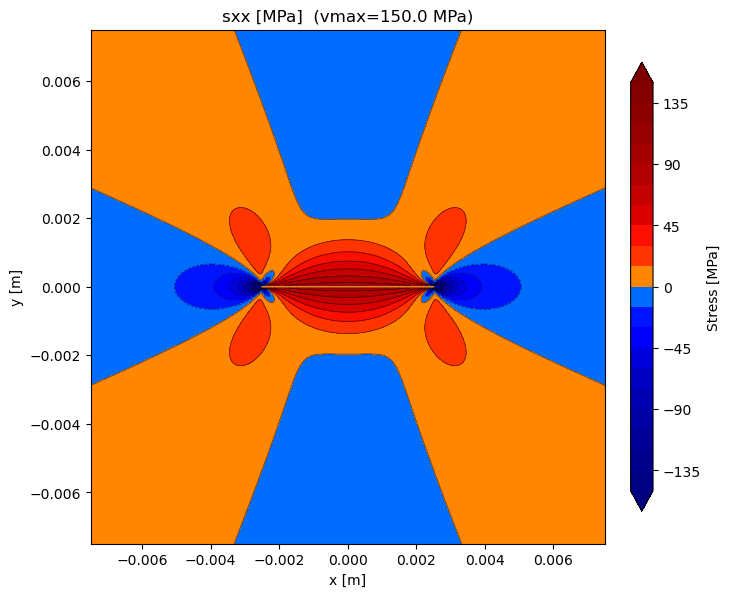

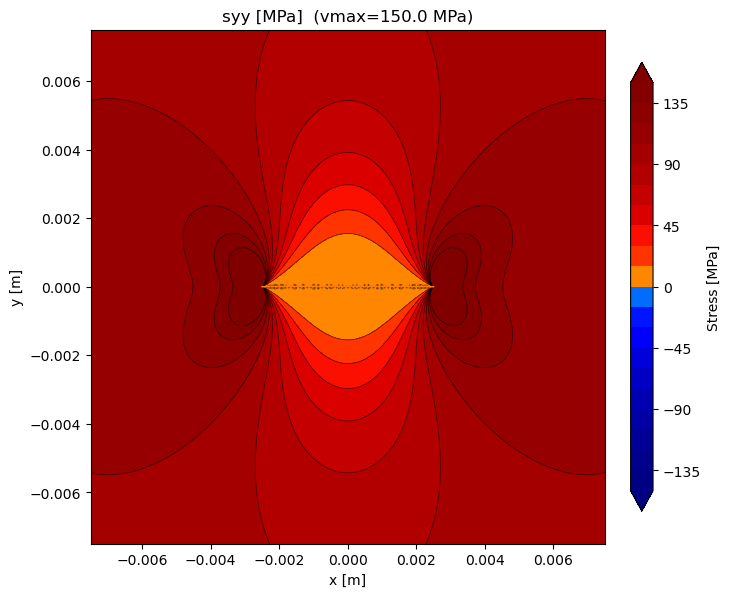

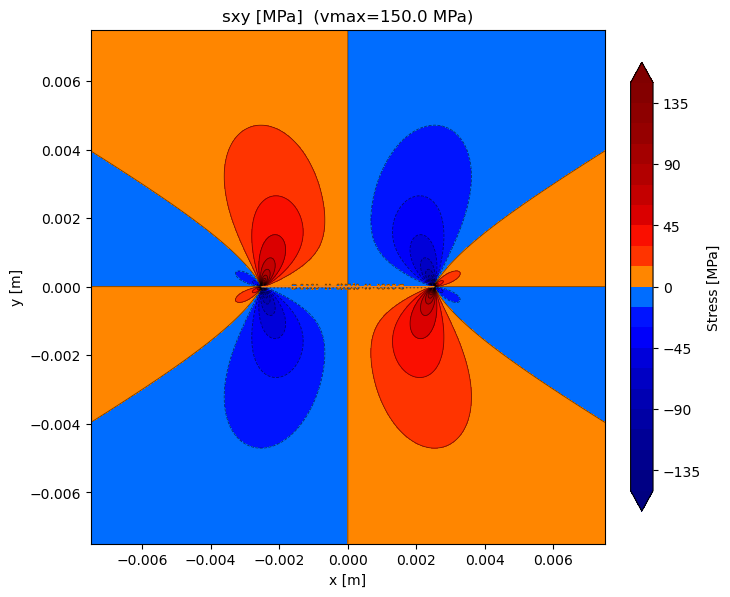

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\single_crack


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils.dce_solver_v2  as dsol
import utils.dce_results_v2 as dres
import utils.dce_plots_v2   as dplt
importlib.reload(dsol); importlib.reload(dres); importlib.reload(dplt)

from utils.dce_solver_v2  import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_results_v2 import DCEResultsV2
from utils.dce_plots_v2   import DCEPlotterV2, StressPlotOpts

# -------------------------
# Output directory (ALL figures saved here)
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\single_crack")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem setup
# -------------------------
ne_half = 10
L = 5e-3  # crack length 2a [m]

material = Material(E=200e9, nu=0.30, plane_stress=False)
crack    = Crack(length=L, angle=0.0, center=(0.0, 0.0))
stress   = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)  # Pa

calc = DCESingleCrackStatic(material, crack, stress)

sol = calc.solve(
    ne_half=ne_half,
    representation="cheb_quad",      # robust baseline
    node_distribution="tip_dense",   # recommended
)
# sol = calc.solve(50)
res = DCEResultsV2(calc, sol)
plotter = DCEPlotterV2(res, out_dir=out_dir)

# -------------------------
# Stress intensity factors
# -------------------------
KI, KII, meta = res.sif_from_cod_fit(tip="right")
print("KI  [MPa√m] =", KI / 1e6)
print("KII [MPa√m] =", KII / 1e6)

# -------------------------
# Basic plots
# -------------------------
plotter.plot_burgers()
plotter.plot_cod_csd(n_theta=8000)
plotter.plot_crack_geometry(n_theta=2000, scale=1.0)  # y-axis in microns
plt.show()

# -------------------------
# Global stress plots (bands + contours)
# -------------------------
opts = StressPlotOpts(
    extent_factor=3,
    n_grid=401,
    add_remote=True,        # IMPORTANT: makes far field ~100 MPa for syy
    mask_crack=True,
    cmap="jet",
    n_bands=20,
    label_contours=False,
    vmax_factor=1.5,        # try 3, 5, 10 for tip emphasis
)

figs = plotter.plot_stress_components_global(
    opts=opts,
    components=("sxx", "syy", "sxy"),
)
plt.show()

print("Saved figures to:", out_dir)
